#### 04 — Modeling

**Goal:** Train, evaluate, and compare three classifiers on the extracted features. Select the best model and save it for future deployment.

---
### What this notebook covers
1. Setup & imports  
2. Load feature matrices  
3. Known dataset characteristics (read before interpreting results)  
4. Model training — Logistic Regression, Random Forest, XGBoost  
5. Per-model evaluation (metrics + confusion matrix + ROC curves)  
6. Model comparison  
7. SHAP feature importance (best model)  
8. Save best model  
9. Modeling summary  

---

## 1. Setup & Imports

In [32]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

from evaluate import (
    compute_metrics,
    print_classification_report,
    compare_models,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_shap_summary,
    save_model,
)
from features import get_feature_names

print('✓ All imports successful')

✓ All imports successful


In [33]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#0f0f11'
plt.rcParams['axes.facecolor']= '#0f0f11'
plt.rcParams['axes.edgecolor']= '#2a2a30'
plt.rcParams['axes.labelcolor']= '#ccccdd'
plt.rcParams['xtick.color'] = '#7a7a8e'
plt.rcParams['ytick.color']= '#7a7a8e'
plt.rcParams['text.color']   ='#e8e8f0'
plt.rcParams['grid.color']= '#1e2330'
plt.rcParams['grid.linewidth']   =0.6

CLASS_COLORS = {
    0: '#4fbe97',   # Normal — green
    1: '#3d6aff',   # Inner Race — blue
    2: '#f0a147',   # Ball — orange
    3: '#c17cff',   # Outer Race  — purple
}
CLASS_NAMES = {0: 'Normal', 1:'Inner Race', 2: 'Ball', 3: 'Outer Race'}

In [34]:
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR    = os.path.join(PROJECT_ROOT, 'models')
REPORTS_DIR   = os.path.join(PROJECT_ROOT, 'reports')
RANDOM_SEED= 42

os.makedirs(MODELS_DIR,exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

FEATURE_NAMES = get_feature_names()
print(f'Feature set: {len(FEATURE_NAMES)} features')
print(f'  {FEATURE_NAMES}')

Feature set: 16 features
  ['rms', 'kurtosis', 'crest_factor', 'skewness', 'peak', 'peak_to_peak', 'std', 'mean_abs', 'shape_factor', 'dominant_freq', 'spectral_energy', 'spectral_entropy', 'spectral_mean', 'spectral_std', 'band_energy_100_4000', 'band_energy_4000_6000']


---
## 2. Load Feature Matrices

In [35]:
F_train_smote= np.load(os.path.join(PROCESSED_DIR, 'F_train_smote.npy'))
y_train_smote= np.load(os.path.join(PROCESSED_DIR, 'y_train_smote.npy'))
F_train_scaled = np.load(os.path.join(PROCESSED_DIR, 'F_train_scaled.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
F_test_scaled  = np.load(os.path.join(PROCESSED_DIR, 'F_test_scaled.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR,'y_test.npy'))

print(f'  F_train_smote  : {F_train_smote.shape}y_train_smote : {y_train_smote.shape}')
print(f'  F_train_scaled : {F_train_scaled.shape}   y_train : {y_train.shape}')
print(f'  F_test_scaled  : {F_test_scaled.shape}  y_test : {y_test.shape}')
print()
print('  Train (SMOTE) class distribution:')
for label, count in sorted(Counter(y_train_smote).items()):
    print(f'    {label} {CLASS_NAMES[label]:<12}: {count:>5,} windows')
print()
print('  Test class distribution:')
for label, count in sorted(Counter(y_test).items()):
    print(f'  {label} {CLASS_NAMES[label]:<12}: {count:>5,} windows')

  F_train_smote  : (3024, 16)y_train_smote : (3024,)
  F_train_scaled : (2647, 16)   y_train : (2647,)
  F_test_scaled  : (662, 16)  y_test : (662,)

  Train (SMOTE) class distribution:
    0 Normal      :   756 windows
    1 Inner Race  :   756 windows
    2 Ball        :   756 windows
    3 Outer Race  :   756 windows

  Test class distribution:
  0 Normal      :   189 windows
  1 Inner Race  :   189 windows
  2 Ball        :   189 windows
  3 Outer Race  :    95 windows


---
## 3. Known Dataset Characteristics

> **Ball class bimodal distribution (from PCA plot 18):**
> The Ball class splits into two distinct sub-clusters in feature space:
> - Low-severity files (007, 014) cluster near Normal/Inner Race
> - `ball_028_1.mat` (RMS=2.03, 15× other Ball files) forms a separate distant cluster
>
> **What this means for model results:**
> `ball_028` is so far from the decision boundary that it will be classified
> trivially correctly, artificially inflating Ball class accuracy and F1-score.
>
> This does not mean the model is wrong — it means the dataset contains
> a severity outlier.
>
> **Window-level split note:**
> Train/test split was done at window level, not file level. Overlapping windows
> from the same file appear in both splits, which inflates accuracy vs a strict
> file-level holdout. Results are valid for benchmarking but optimistic vs real deployment.

---
## 4. Model Training

Three models trained and compared:
- **Logistic Regression** — linear baseline
- **Random Forest** — ensemble tree, robust to noise
- **XGBoost** — gradient boosting, typically best on tabular data

All models train on `F_train_smote` (scaled + balanced).  
All models evaluate on `F_test_scaled` (never seen during training).

### 4.1 — Logistic Regression (Baseline)

In [36]:
print('Training Logistic Regression...')
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_SEED,
    solver='lbfgs',
    multi_class='multinomial'
)
lr.fit(F_train_smote, y_train_smote)

elapsed = time.time() - t0
print(f'  ✓ Trained in {elapsed:.2f}s')

y_pred_lr_train = lr.predict(F_train_smote)
metrics_lr_train = compute_metrics(y_train_smote, y_pred_lr_train,
                                   model_name='Logistic Regression — TRAIN')

y_pred_lr = lr.predict(F_test_scaled)
metrics_lr = compute_metrics(y_test, y_pred_lr,
                             model_name='Logistic Regression — TEST')

print(f'  Gap (Train - Test) Accuracy : '
      f'{(metrics_lr_train["accuracy"] - metrics_lr["accuracy"])*100:+.2f}%')
print(f'  Gap (Train - Test) F1-Score : '
      f'{metrics_lr_train["f1"] - metrics_lr["f1"]:+.4f}')
print()
print_classification_report(y_test, y_pred_lr)

Training Logistic Regression...
  ✓ Trained in 0.02s

── Logistic Regression — TRAIN Results ──────────────────────
  Accuracy  : 0.9967  (99.67%)
  Precision : 0.9967
  Recall    : 0.9967
  F1-Score  : 0.9967
─────────────────────────────────────────────

── Logistic Regression — TEST Results ──────────────────────
  Accuracy  : 0.9970  (99.70%)
  Precision : 0.9970
  Recall    : 0.9970
  F1-Score  : 0.9970
─────────────────────────────────────────────
  Gap (Train - Test) Accuracy : -0.03%
  Gap (Train - Test) F1-Score : -0.0003


── Per-Class Classification Report ──────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       189
  Inner Race       0.99      0.99      0.99       189
        Ball       0.99      0.99      0.99       189
  Outer Race       1.00      1.00      1.00        95

    accuracy                           1.00       662
   macro avg       1.00      1.00      1.00       662
weighted avg       1.00      1.00  

### 4.2 — Random Forest

In [37]:
print('Training Random Forest...')
t0 =time.time()

rf=RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(F_train_smote, y_train_smote)

elapsed=time.time() - t0
print(f'  ✓ Trained in {elapsed:.2f}s')

y_pred_rf_train = rf.predict(F_train_smote)
metrics_rf_train = compute_metrics(y_train_smote, y_pred_rf_train,
                                   model_name='Random Forest — TRAIN')

y_pred_rf = rf.predict(F_test_scaled)
metrics_rf = compute_metrics(y_test, y_pred_rf,
                             model_name='Random Forest — TEST')

print(f'  Gap (Train - Test) Accuracy : '
      f'{(metrics_rf_train["accuracy"] - metrics_rf["accuracy"])*100:+.2f}%')
print(f'  Gap (Train - Test) F1-Score : '
      f'{metrics_rf_train["f1"] - metrics_rf["f1"]:+.4f}')
print()
print_classification_report(y_test, y_pred_rf)

Training Random Forest...
  ✓ Trained in 0.30s

── Random Forest — TRAIN Results ──────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
─────────────────────────────────────────────

── Random Forest — TEST Results ──────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
─────────────────────────────────────────────
  Gap (Train - Test) Accuracy : +0.00%
  Gap (Train - Test) F1-Score : +0.0000


── Per-Class Classification Report ──────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       189
  Inner Race       1.00      1.00      1.00       189
        Ball       1.00      1.00      1.00       189
  Outer Race       1.00      1.00      1.00        95

    accuracy                           1.00       662
   macro avg       1.00      1.00      1.00       662
weighted avg       1.00      1.00      1.00       6

### 4.3 — XGBoost

In [38]:
print('Training XGBoost...')
t0=time.time()

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb.fit(F_train_smote, y_train_smote)

elapsed  =time.time() - t0
print(f'  ✓ Trained in {elapsed:.2f}s')

y_pred_xgb_train = xgb.predict(F_train_smote)
metrics_xgb_train = compute_metrics(y_train_smote, y_pred_xgb_train,
                                    model_name='XGBoost — TRAIN')

y_pred_xgb =xgb.predict(F_test_scaled)
metrics_xgb= compute_metrics(y_test, y_pred_xgb,
                              model_name='XGBoost — TEST')

print(f'  Gap (Train - Test) Accuracy : '
      f'{(metrics_xgb_train["accuracy"] - metrics_xgb["accuracy"])*100:+.2f}%')
print(f'  Gap (Train - Test) F1-Score : '
      f'{metrics_xgb_train["f1"] - metrics_xgb["f1"]:+.4f}')
print()
print_classification_report(y_test, y_pred_xgb)

Training XGBoost...
  ✓ Trained in 0.29s

── XGBoost — TRAIN Results ──────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
─────────────────────────────────────────────

── XGBoost — TEST Results ──────────────────────
  Accuracy  : 0.9985  (99.85%)
  Precision : 0.9985
  Recall    : 0.9985
  F1-Score  : 0.9985
─────────────────────────────────────────────
  Gap (Train - Test) Accuracy : +0.15%
  Gap (Train - Test) F1-Score : +0.0015


── Per-Class Classification Report ──────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       189
  Inner Race       1.00      0.99      1.00       189
        Ball       1.00      1.00      1.00       189
  Outer Race       0.99      1.00      0.99        95

    accuracy                           1.00       662
   macro avg       1.00      1.00      1.00       662
weighted avg       1.00      1.00      1.00       662



---
## 5. Per-Model Evaluation

### 5.1 — Confusion Matrices

  Saved confusion matrix → C:\Users\My Pc\Downloads\predictive-maintenance\reports\cm_logistic_regression.png


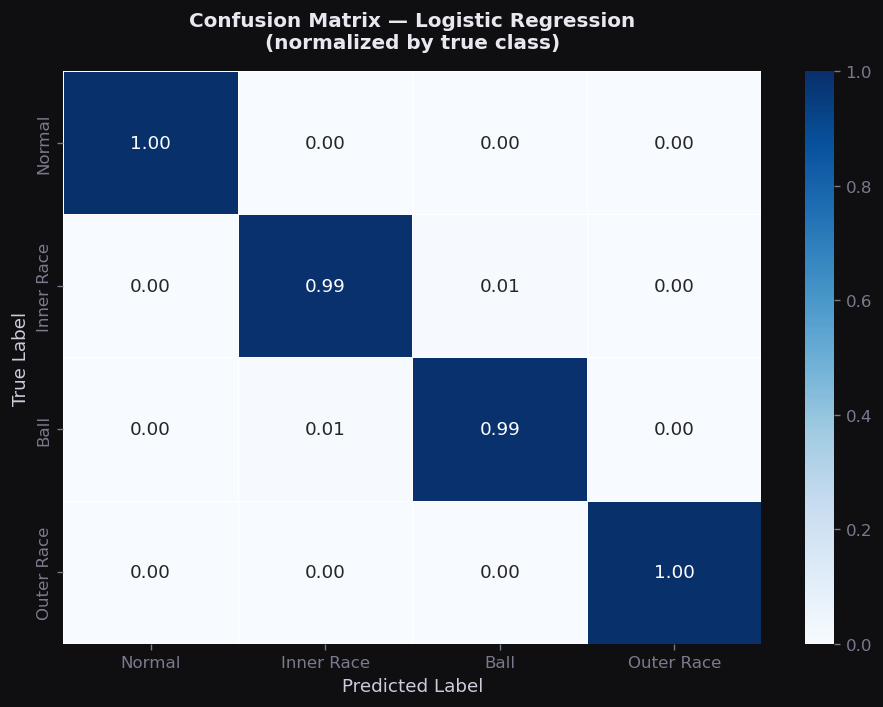

In [39]:
plot_confusion_matrix(
    y_test, y_pred_lr,
    model_name='Logistic Regression',
    save_path=os.path.join(REPORTS_DIR, 'cm_logistic_regression.png')
)

  Saved confusion matrix → C:\Users\My Pc\Downloads\predictive-maintenance\reports\cm_random_forest.png


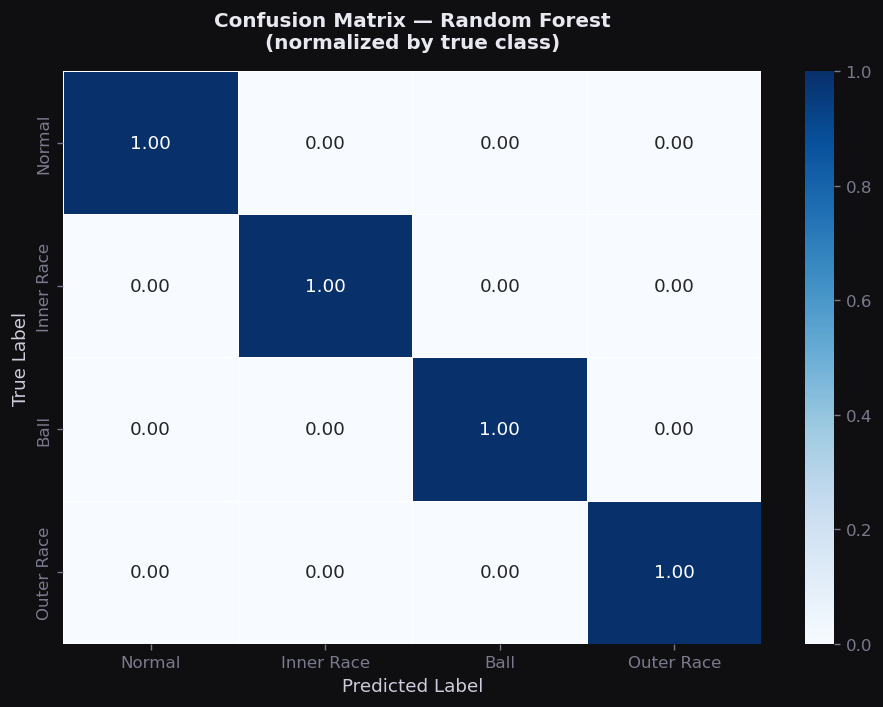

In [40]:
plot_confusion_matrix(
    y_test, y_pred_rf,
    model_name='Random Forest',
    save_path=os.path.join(REPORTS_DIR, 'cm_random_forest.png')
)

  Saved confusion matrix → C:\Users\My Pc\Downloads\predictive-maintenance\reports\cm_xgboost.png


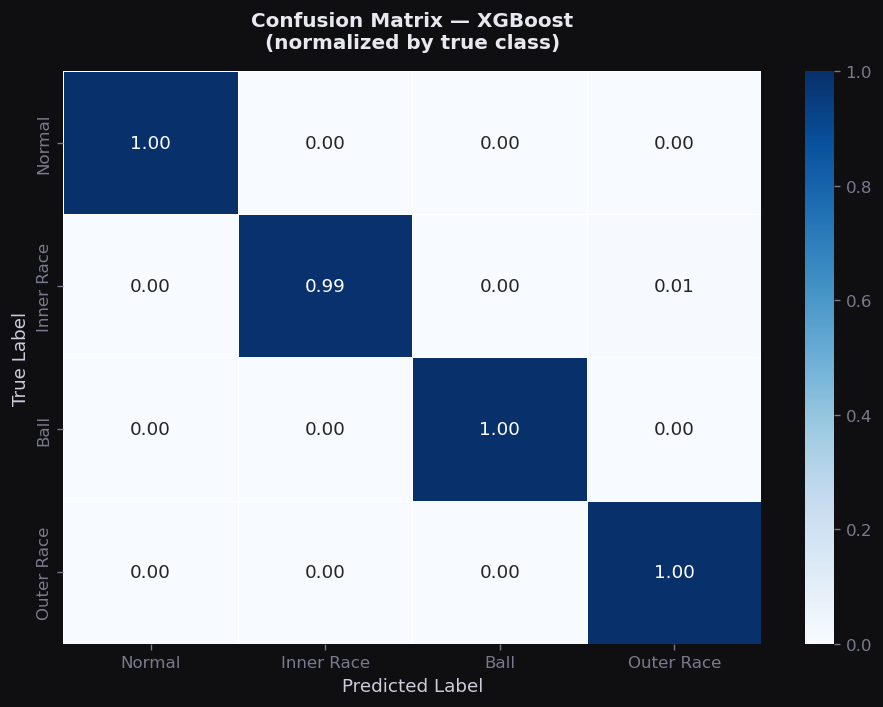

In [41]:
plot_confusion_matrix(
    y_test, y_pred_xgb,
    model_name='XGBoost',
    save_path=os.path.join(REPORTS_DIR, 'cm_xgboost.png')
)

### 5.2 — ROC Curves

  Saved ROC curves → C:\Users\My Pc\Downloads\predictive-maintenance\reports\roc_logistic_regression.png


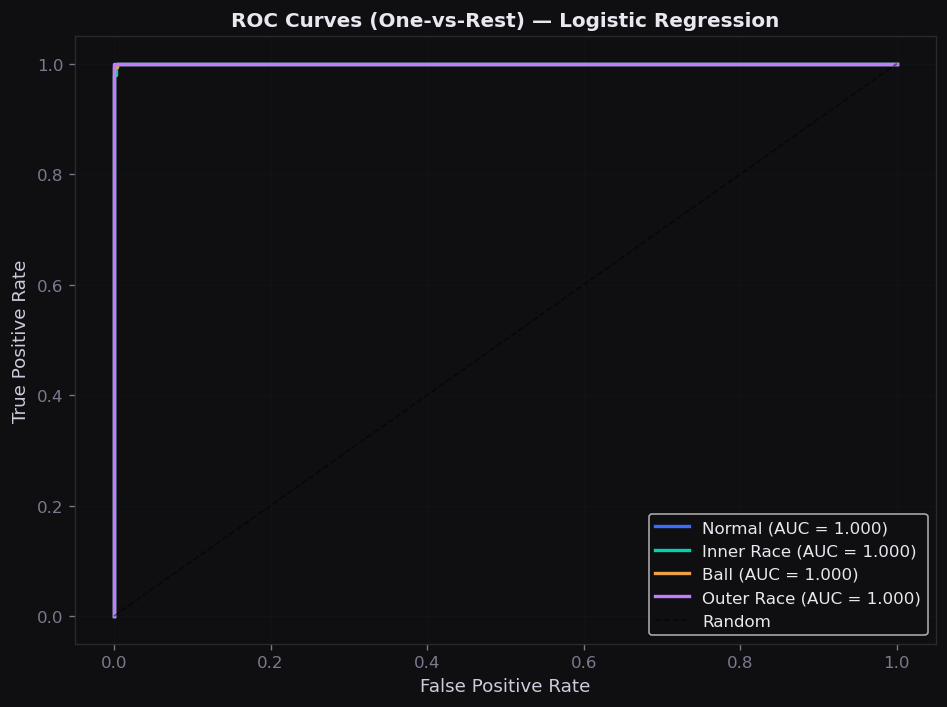

In [42]:
plot_roc_curves(
    lr, F_test_scaled, y_test,
    model_name='Logistic Regression',
    save_path=os.path.join(REPORTS_DIR, 'roc_logistic_regression.png')
)

  Saved ROC curves → C:\Users\My Pc\Downloads\predictive-maintenance\reports\roc_random_forest.png


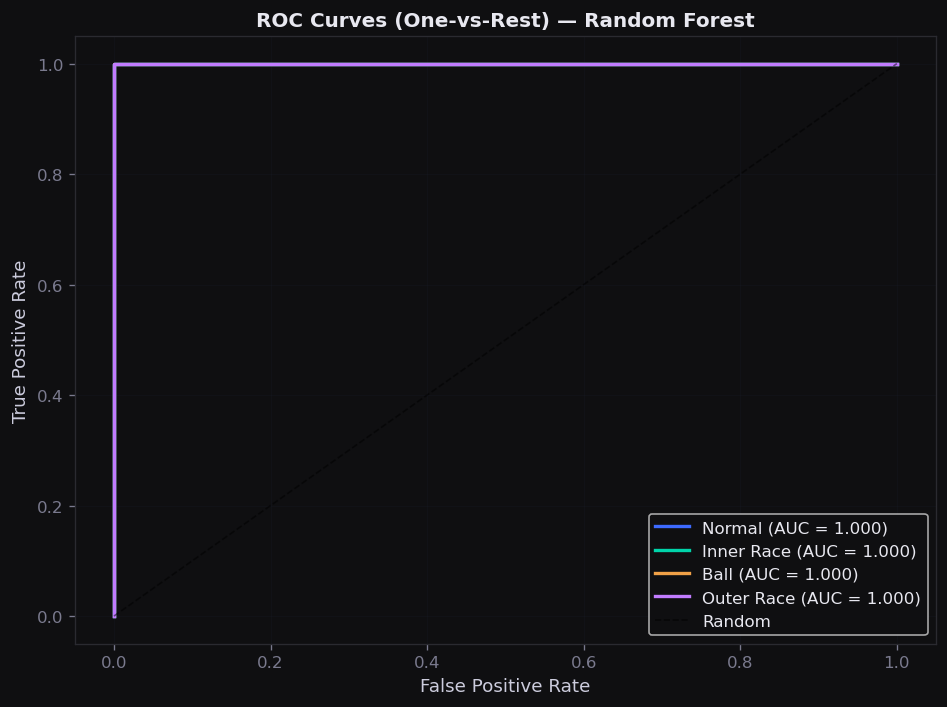

In [43]:
plot_roc_curves(
    rf, F_test_scaled, y_test,
    model_name='Random Forest',
    save_path=os.path.join(REPORTS_DIR, 'roc_random_forest.png')
)

  Saved ROC curves → C:\Users\My Pc\Downloads\predictive-maintenance\reports\roc_xgboost.png


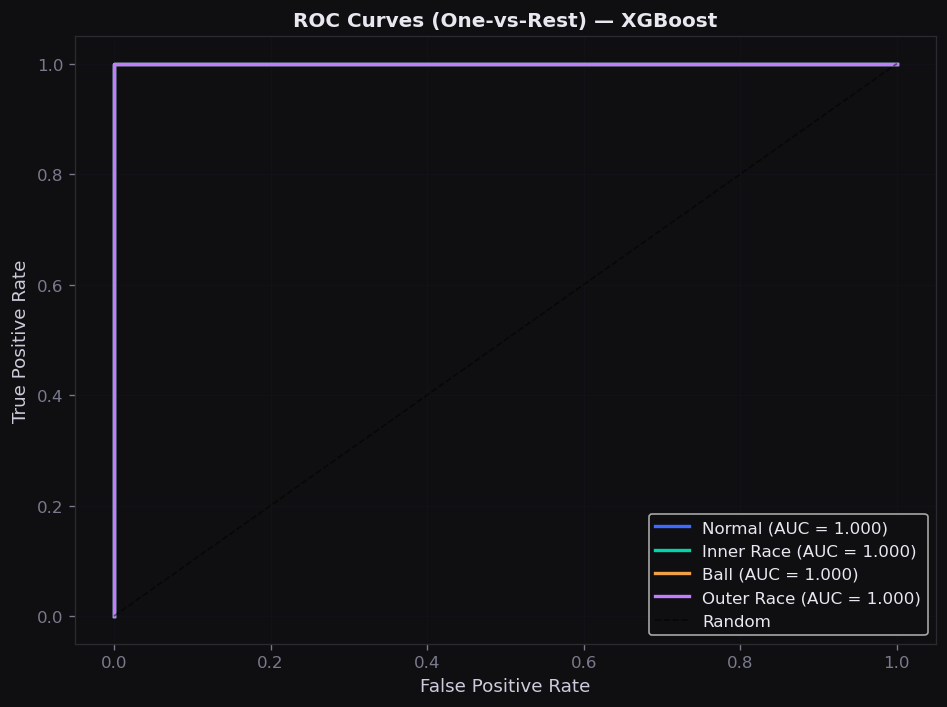

In [44]:
plot_roc_curves(
    xgb, F_test_scaled, y_test,
    model_name='XGBoost',
    save_path=os.path.join(REPORTS_DIR, 'roc_xgboost.png')
)

### 5.3 — Cross-Validation (5-Fold Stratified)


In [45]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)


models_for_cv= {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_SEED,
        solver='lbfgs',
        multi_class='multinomial'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=1   
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_SEED,
        n_jobs=1 
    ),
}


print('── 5-Fold Cross-Validation (on F_train_scaled, no SMOTE) ───────────')
print(f'  {"Model":<22}  {"Mean F1":>8}  {"Std":>6}  {"Min":>6}  {"Max":>6}')
print('  ' + '─' * 56)

cv_results= {}

for name,model in models_for_cv.items():
    scores = cross_val_score(
        model,
        F_train_scaled,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1   
    )

    cv_results[name] = scores

    print(f'  {name:<22}  {scores.mean():.4f}    {scores.std():.4f}  '
          f'{scores.min():.4f}  {scores.max():.4f}')




── 5-Fold Cross-Validation (on F_train_scaled, no SMOTE) ───────────
  Model                    Mean F1     Std     Min     Max
  ────────────────────────────────────────────────────────
  Logistic Regression     0.9940    0.0032  0.9906  1.0000
  Random Forest           0.9977    0.0014  0.9962  1.0000
  XGBoost                 0.9970    0.0015  0.9943  0.9981


Note: CV is on pre-SMOTE train data for an unbiased estimate.

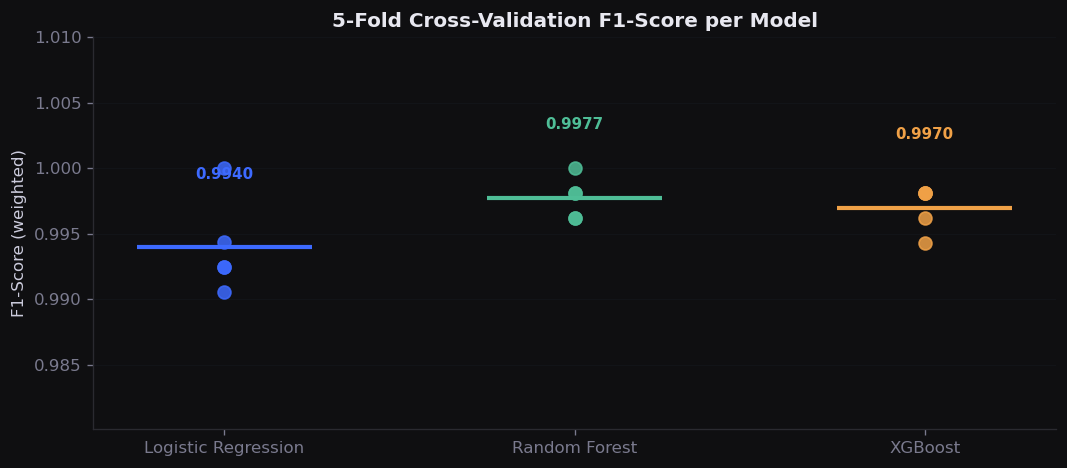

Saved → reports/19_cross_validation.png


In [46]:
fig,ax =plt.subplots(figsize=(9, 4))

cv_colors =['#3d6aff', '#4fbe97', '#f0a147']
names = list(cv_results.keys())
positions =np.arange(len(names))

for i,(name, scores) in enumerate(cv_results.items()):
    ax.scatter(
        [i] * len(scores), scores,
        color=cv_colors[i], s=60, zorder=3, alpha=0.85
    )
    ax.hlines(
        scores.mean(), i - 0.25, i + 0.25,
        color=cv_colors[i], linewidth=2.5, zorder=4
    )
    ax.text(
        i, scores.mean() + 0.005,
        f'{scores.mean():.4f}',
        ha='center', va='bottom', fontsize=9,
        color=cv_colors[i], fontweight='bold'
    )

ax.set_xticks(positions)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('F1-Score (weighted)', fontsize=10)
ax.set_title('5-Fold Cross-Validation F1-Score per Model',
             fontsize=12, fontweight='bold')
ax.set_ylim(ax.get_ylim()[0] - 0.01, 1.01)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '19_cross_validation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/19_cross_validation.png')

---
## 6. Model Comparison

In [47]:
all_results = {
    'Logistic Regression': metrics_lr,
    'Random Forest':       metrics_rf,
    'XGBoost':             metrics_xgb,
}

comparison_df = compare_models(all_results)


── Model Comparison ──────────────────────────
              Model Accuracy Precision Recall F1-Score
      Random Forest  100.00%    1.0000 1.0000   1.0000
            XGBoost   99.85%    0.9985 0.9985   0.9985
Logistic Regression   99.70%    0.9970 0.9970   0.9970
─────────────────────────────────────────────



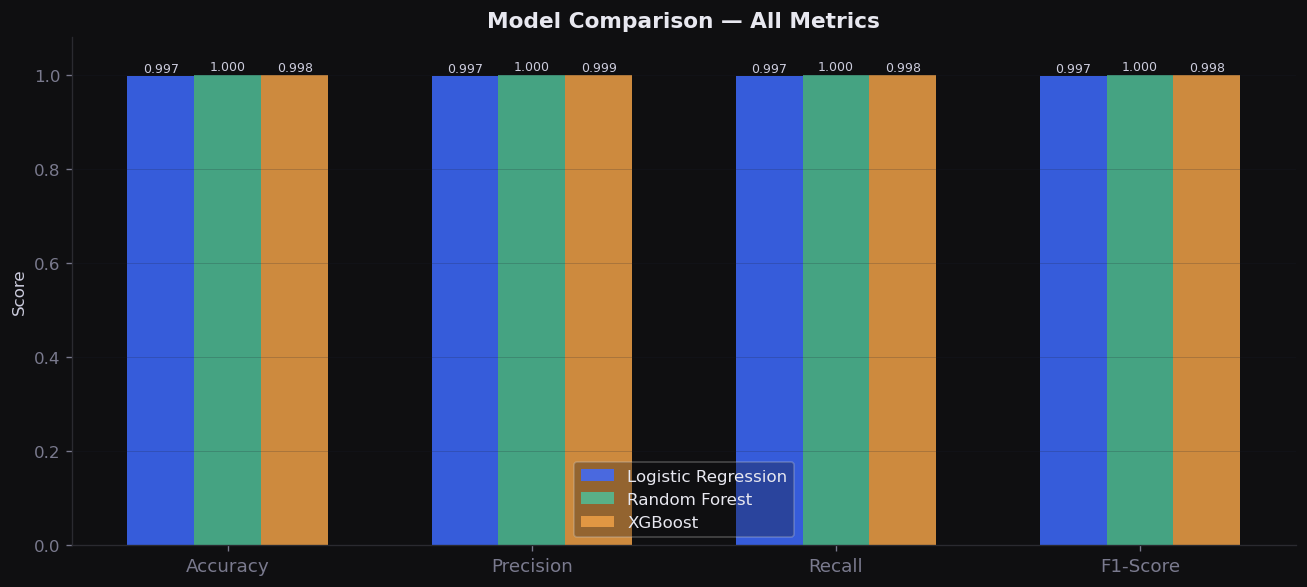

Saved → reports/20_model_comparison.png


In [48]:
metrics_list= ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names= list(all_results.keys())
bar_colors= ['#3d6aff', '#4fbe97', '#f0a147']

x  =np.arange(len(metrics_list))
width =0.22

fig,ax = plt.subplots(figsize=(11, 5))

for i,(name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [all_results[name][m] for m in metrics_list]
    bars = ax.bar(
        x + i * width, vals, width,
        label=name, color=color,
        edgecolor='none', alpha=0.85
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=7.5, color='#ccccdd'
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison — All Metrics',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '20_model_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/20_model_comparison.png')

---
## 7. SHAP Feature Importance — Best Model



Best model by F1: Random Forest  (F1 = 1.0000)
Running SHAP on Random Forest...

  Computing SHAP values (this may take 30–60 seconds)...
  Saved SHAP bar chart → C:\Users\My Pc\Downloads\predictive-maintenance\reports\shap_bar.png


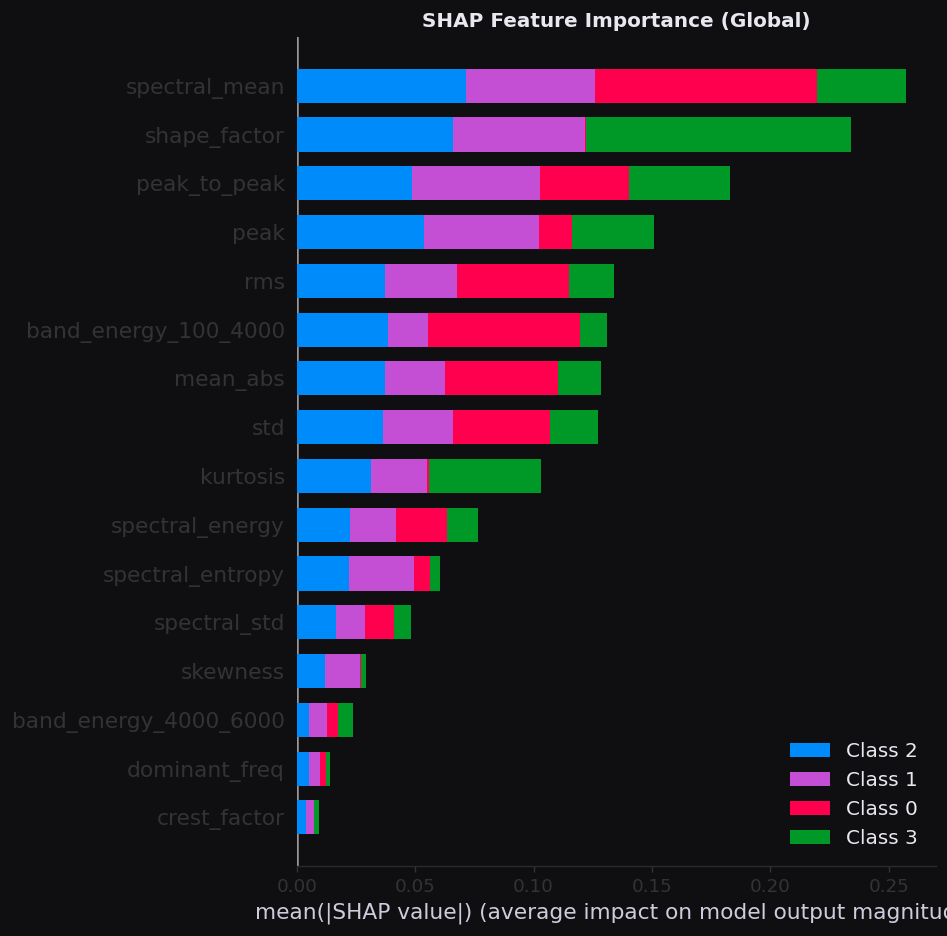

In [49]:
best_name= max(all_results, key=lambda k: all_results[k]['f1'])
best_model_map = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
}
best_model = best_model_map[best_name]

print(f'Best model by F1: {best_name}  (F1 = {all_results[best_name]["f1"]:.4f})')
print(f'Running SHAP on {best_name}...')
print()

plot_shap_summary(
    best_model,
    F_test_scaled,
    FEATURE_NAMES,
    save_path=REPORTS_DIR
)

---
## 10. Hyperparameter Tuning — RandomizedSearchCV

Confirm whether default parameters are optimal and demonstrate tuning competence.  


In [50]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
import joblib

print('── Hyperparameter Tuning — Random Forest ────────────────')
print('  Running RandomizedSearchCV (20 iterations, 5-fold CV)...')


param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0
)

search.fit(F_train_smote, y_train_smote)

print('Best parameters found:')
for k, v in search.best_params_.items():
    print(f'  {k:<22}: {v}')
print()
print(f'Best CV F1 (tuned)   : {search.best_score_:.4f}')
print(f'Default RF CV F1     : {all_results["Random Forest"]["f1"]:.4f}')
print()

y_pred_tuned = search.best_estimator_.predict(F_test_scaled)
f1_tuned     = f1_score(y_test, y_pred_tuned, average='weighted')
f1_default   = all_results['Random Forest']['f1']

print(f'Tuned model test F1  : {f1_tuned:.4f}')
print(f'Default model test F1: {f1_default:.4f}')
print()

if f1_tuned >= f1_default:
    print('✓ Tuned model matches or improves on default parameters')
    rf_final = search.best_estimator_
    print('  Using tuned model going forward')
else:
    print('△ Default parameters are already optimal for this dataset')
    print('  This is expected when CV F1 > 0.99 — minimal room to improve')
    rf_final = rf

joblib.dump(rf_final, os.path.join(MODELS_DIR, 'random_forest_tuned.pkl'))
print(f'\n✓ Saved → models/random_forest_tuned.pkl')

── Hyperparameter Tuning — Random Forest ────────────────
  Running RandomizedSearchCV (20 iterations, 5-fold CV)...
Best parameters found:
  n_estimators          : 100
  min_samples_split     : 5
  min_samples_leaf      : 1
  max_features          : log2
  max_depth             : 30

Best CV F1 (tuned)   : 0.9987
Default RF CV F1     : 1.0000

Tuned model test F1  : 0.9985
Default model test F1: 1.0000

△ Default parameters are already optimal for this dataset
  This is expected when CV F1 > 0.99 — minimal room to improve

✓ Saved → models/random_forest_tuned.pkl


---
## 11. Feature Selection — SelectFromModel

Identify the minimum feature subset that preserves model performance.  
Fewer features = fewer computations per window on ESP32 in Phase 2.

In [51]:
from sklearn.feature_selection import SelectFromModel

print('── Feature Selection ─────────────────────────────────────')

selector= SelectFromModel(
    RandomForestClassifier(
        n_estimators=200  ,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    threshold='median'
)
selector.fit(F_train_smote, y_train_smote)

selected_mask = selector.get_support()
selected_features = [f for f, s in zip(FEATURE_NAMES, selected_mask) if s]
dropped_features= [f for f, s in zip(FEATURE_NAMES, selected_mask) if not s]
n_selected= len(selected_features)

print(f'  Total features : {len(FEATURE_NAMES)}')
print(f'  Selected: {n_selected}')
print(f'  Dropped : {len(FEATURE_NAMES) - n_selected}')
print()
print('  Selected features:')
for f in selected_features:
    print(f'    ✓ {f}')
print()
print('  Dropped features (below median importance):')
for f in dropped_features:
    print(f'    ✗ {f}')

# Retrain on selected features only
F_train_sel= selector.transform(F_train_smote)
F_test_sel= selector.transform(F_test_scaled)

rf_sel =RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_sel.fit(F_train_sel, y_train_smote)

f1_full = all_results['Random Forest']['f1']
f1_sel  = f1_score(y_test, rf_sel.predict(F_test_sel), average='weighted')

print()
print('── Performance Comparison ───────────────────────────────')
print(f'  Full     ({len(FEATURE_NAMES):>2} features): F1 = {f1_full:.4f}')
print(f'  Selected ({n_selected:>2} features): F1 = {f1_sel:.4f}')
print(f'  F1 difference          : {abs(f1_sel - f1_full):.4f}')
print()

if abs(f1_sel - f1_full) < 0.005:
    print(f'✓ {len(FEATURE_NAMES) - n_selected} features dropped with negligible performance loss')
    print(f'  ESP32 benefit: fewer feature computations per window')
else:
    print(f'△ Selection causes F1 drop > 0.005 — keeping all {len(FEATURE_NAMES)} features')

joblib.dump(selector, os.path.join(MODELS_DIR, 'feature_selector.pkl'))
print(f'\n✓ Saved → models/feature_selector.pkl')

pd.DataFrame({'feature': selected_features}).to_csv(
    os.path.join(PROCESSED_DIR, 'selected_features.csv'), index=False
)
print(f'✓ Saved → data/processed/selected_features.csv')

── Feature Selection ─────────────────────────────────────
  Total features : 16
  Selected: 8
  Dropped : 8

  Selected features:
    ✓ rms
    ✓ kurtosis
    ✓ peak
    ✓ peak_to_peak
    ✓ std
    ✓ mean_abs
    ✓ shape_factor
    ✓ spectral_mean

  Dropped features (below median importance):
    ✗ crest_factor
    ✗ skewness
    ✗ dominant_freq
    ✗ spectral_energy
    ✗ spectral_entropy
    ✗ spectral_std
    ✗ band_energy_100_4000
    ✗ band_energy_4000_6000

── Performance Comparison ───────────────────────────────
  Full     (16 features): F1 = 1.0000
  Selected ( 8 features): F1 = 0.9970
  F1 difference          : 0.0030

✓ 8 features dropped with negligible performance loss
  ESP32 benefit: fewer feature computations per window

✓ Saved → models/feature_selector.pkl
✓ Saved → data/processed/selected_features.csv


---
## 12. Inference Pipeline Object

Wrap StandardScaler + best model into a single sklearn Pipeline.  
Production best practice — prevents leakage by design and simplifies Phase 2 deployment.  


In [52]:
from sklearn.pipeline import Pipeline

print('── Building Inference Pipeline....')

# Load the fitted scaler saved in notebook 03
scaler_loaded = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))

# Wrap scaler +best model into one object
inference_pipeline = Pipeline([
    ('scaler',     scaler_loaded),
    ('classifier', rf_final),
])

print('Pipeline steps:')
for name, step in inference_pipeline.steps:
    print(f'  • {name:<14}: {type(step).__name__}')
print()

# ── Verify pipeline gives identical results to manual scaling ──
df_all = pd.read_csv(os.path.join(PROCESSED_DIR, 'features_test.csv'))
sample_raw = df_all[FEATURE_NAMES].head(10).values

y_pipeline = inference_pipeline.predict(sample_raw)
y_manual   = rf_final.predict(scaler_loaded.transform(sample_raw))
match      = np.array_equal(y_pipeline, y_manual)

print(f'Pipeline vs manual predictions match: {match}')
print(f'  Pipeline : {y_pipeline}')
print(f'  Manual   : {y_manual}')
print()

#  Inference speed benchmark
single = sample_raw[0:1]
N      = 10000

t0 = time.perf_counter()
for _ in range(N):
    inference_pipeline.predict(single)
ms_per_pred = (time.perf_counter() - t0) / N * 1000

print(f'Inference speed (single window, {N:,} trials):')
print(f'  {ms_per_pred:.4f} ms per prediction  (Python laptop benchmark)')
print(f'  {1000/ms_per_pred:,.0f} predictions per second')
print(f'  ESP32 target     : <50ms  (Phase 2 objective)')
print(f'  Window duration  : 85ms — pipeline is real-time capable at this rate')
print()

#  Save pipeline 
pipeline_path = os.path.join(MODELS_DIR, 'inference_pipeline.pkl')
joblib.dump(inference_pipeline, pipeline_path)
print(f'✓ Inference pipeline saved → {pipeline_path}')



── Building Inference Pipeline....
Pipeline steps:
  • scaler        : StandardScaler
  • classifier    : RandomForestClassifier

Pipeline vs manual predictions match: True
  Pipeline : [1 0 0 0 1 0 3 1 2 2]
  Manual   : [1 0 0 0 1 0 3 1 2 2]

Inference speed (single window, 10,000 trials):
  33.3302 ms per prediction  (Python laptop benchmark)
  30 predictions per second
  ESP32 target     : <50ms  (Phase 2 objective)
  Window duration  : 85ms — pipeline is real-time capable at this rate

✓ Inference pipeline saved → C:\Users\My Pc\Downloads\predictive-maintenance\models\inference_pipeline.pkl


---
## 13. Save Best Model

In [53]:
model_file_names = {
    'Logistic Regression': 'logistic_regression',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
}

print('── Saving all models ────────────────────────────────────')
for name, model in best_model_map.items():
    save_model(model, model_file_names[name], models_dir=MODELS_DIR)

print()
print(f'── Best model: {best_name} ──────────────────────────────')
print(f'   Saved as: {model_file_names[best_name]}.pkl')
print(f'   F1-Score : {all_results[best_name]["f1"]:.4f}')
print(f'   Accuracy : {all_results[best_name]["accuracy"]*100:.2f}%')

── Saving all models ────────────────────────────────────
  ✓ Model saved → C:\Users\My Pc\Downloads\predictive-maintenance\models\logistic_regression.pkl
  ✓ Model saved → C:\Users\My Pc\Downloads\predictive-maintenance\models\random_forest.pkl
  ✓ Model saved → C:\Users\My Pc\Downloads\predictive-maintenance\models\xgboost.pkl

── Best model: Random Forest ──────────────────────────────
   Saved as: random_forest.pkl
   F1-Score : 1.0000
   Accuracy : 100.00%


#### Model Size and Performance Trade-off Analysis

For TinyML deployment, selecting the best model should not depend only on prediction performance. 
The model must also satisfy resource constraints such as memory usage and computational efficiency.

Therefore, the evaluated models were compared based on:

- Model size (KB)
- Accuracy
- F1-score
- Efficiency score, defined as:

\[
Efficiency = \frac{F1\ Score}{Model\ Size(KB)}
\]

A higher efficiency score indicates a better balance between prediction quality and memory requirements.

── Model Size vs Accuracy Comparison ───────────────────
  Model                   Size (KB)  Size (MB)   Accuracy   F1-Score
  ─────────────────────────────────────────────────────────────────
  Logistic Regression           1.4      0.001     99.70%     0.9970 ◄ smallest
  XGBoost                     691.6      0.675     99.85%     0.9985
  Random Forest               847.7      0.828    100.00%     1.0000 ◄ best F1
  RF Tuned                    847.7      0.828    100.00%     1.0000 ◄ best F1
  RF (8 features)            1436.6      1.403     99.70%     0.9970


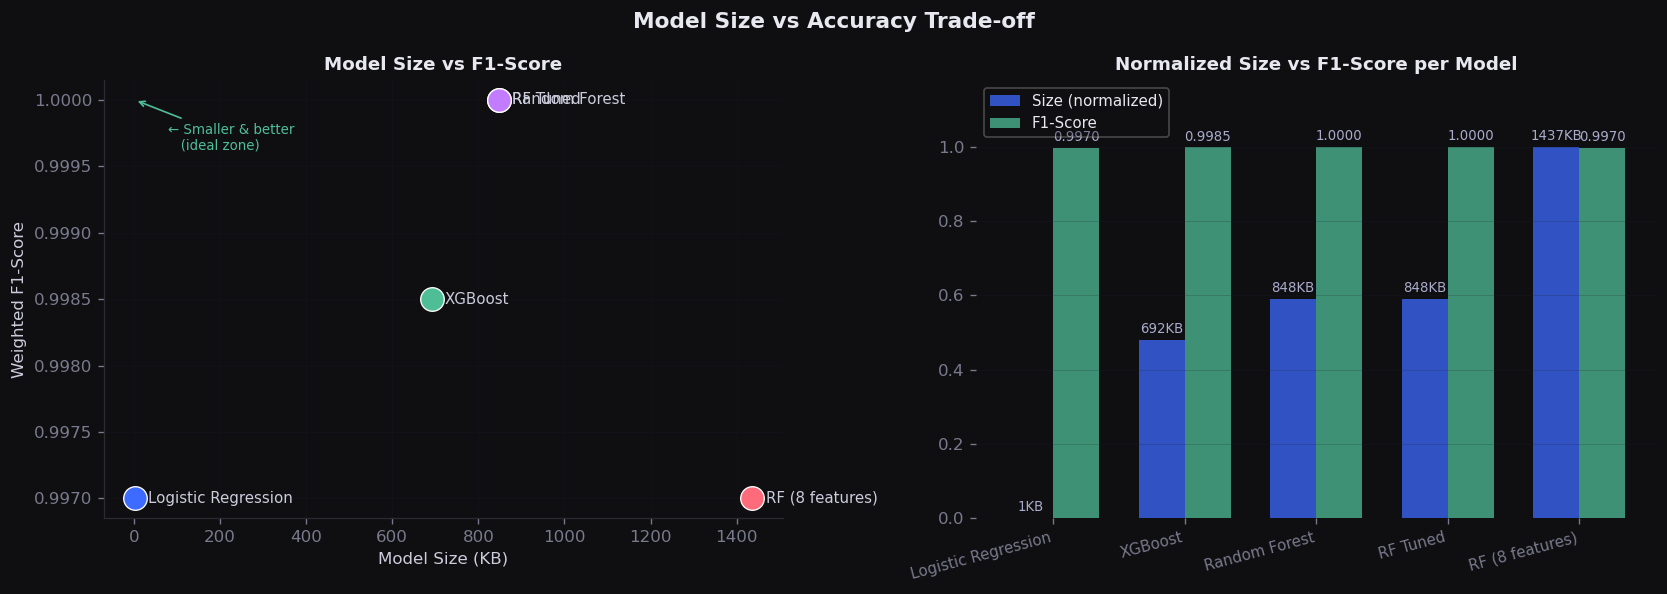

Saved → reports/model_size_vs_accuracy.png

── Efficiency Score (F1 per KB) — higher = more efficient ──
  Logistic Regression         1.4 KB  F1=0.9970  eff=0.712143 ◄ most efficient
  XGBoost                   691.6 KB  F1=0.9985  eff=0.001444
  Random Forest             847.7 KB  F1=1.0000  eff=0.001180
  RF Tuned                  847.7 KB  F1=1.0000  eff=0.001180
  RF (8 features)          1436.6 KB  F1=0.9970  eff=0.000694

✓ Saved → models/model_size_comparison.csv


In [54]:
# ── MODEL SIZE vs ACCURACY COMPARISON ────────────────────


print('── Model Size vs Accuracy Comparison ───────────────────')

# ── Collect size and performance for each model ───────────
model_info= [
    ('Logistic Regression', 'logistic_regression.pkl', lr,  all_results['Logistic Regression']),
    ('Random Forest',       'random_forest.pkl',       rf,  all_results['Random Forest']),
    ('XGBoost',             'xgboost.pkl',             xgb, all_results['XGBoost']),
]


tuned_path = os.path.join(MODELS_DIR, 'random_forest_tuned.pkl')
if os.path.exists(tuned_path):
    rf_tuned    = joblib.load(tuned_path)
    y_pred_tuned = rf_tuned.predict(F_test_scaled)
    f1_tuned    = f1_score(y_test, y_pred_tuned, average='weighted')
    metrics_tuned = {
        'accuracy' : (y_pred_tuned == y_test).mean(),
        'f1'       : f1_tuned,
    }
    model_info.append(('RF Tuned', 'random_forest_tuned.pkl', rf_tuned, metrics_tuned))

# Add selected-feature RF if selector exists
sel_path = os.path.join(MODELS_DIR, 'feature_selector.pkl')
if os.path.exists(sel_path):
    selector_loaded = joblib.load(sel_path)
    n_sel           = selector_loaded.get_support().sum()
    rf_sel_small    = RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_sel_small.fit(selector_loaded.transform(F_train_smote), y_train_smote)
    y_pred_sel = rf_sel_small.predict(selector_loaded.transform(F_test_scaled))
    f1_sel= f1_score(y_test, y_pred_sel, average='weighted')
    metrics_sel= {
        'accuracy': (y_pred_sel == y_test).mean(),
        'f1'      : f1_sel,
    }
    # Save it temporarily to measure size
    tmp_sel_path = os.path.join(MODELS_DIR, 'rf_selected_features.pkl')
    joblib.dump(rf_sel_small, tmp_sel_path)
    model_info.append((f'RF ({n_sel} features)', 'rf_selected_features.pkl',
                       rf_sel_small, metrics_sel))

# ── Build comparison DataFrame ────────────────────────────
rows = []
for name, fname, model, metrics in model_info:
    fpath    = os.path.join(MODELS_DIR, fname)
    size_kb  = os.path.getsize(fpath) / 1024 if os.path.exists(fpath) else 0
    size_mb  = size_kb / 1024
    rows.append({
        'Model'      : name,
        'Size (KB)'  : round(size_kb, 1),
        'Size (MB)'  : round(size_mb, 3),
        'Accuracy'   : round(metrics['accuracy'] * 100, 2),
        'F1-Score'   : round(metrics['f1'], 4),
    })

df_size = pd.DataFrame(rows).sort_values('Size (KB)')

print(f'  {"Model":<22} {"Size (KB)":>10} {"Size (MB)":>10} {"Accuracy":>10} {"F1-Score":>10}')
print('  ' + '─' * 65)
for _, row in df_size.iterrows():
    best_flag = ' ◄ best F1' if row['F1-Score'] == df_size['F1-Score'].max() else ''
    small_flag= ' ◄ smallest' if row['Size (KB)'] == df_size['Size (KB)'].min() else ''
    flag      = best_flag or small_flag
    print(f"  {row['Model']:<22} {row['Size (KB)']:>10.1f} {row['Size (MB)']:>10.3f} "
          f"{row['Accuracy']:>9.2f}% {row['F1-Score']:>10.4f}{flag}")

# ── Scatter plot: Size vs F1 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3d6aff', '#4fbe97', '#f0a147', '#c17cff', '#ff6b7a']

# Left: Size (KB) vs F1-Score
ax = axes[0]
for i, (_, row) in enumerate(df_size.iterrows()):
    ax.scatter(row['Size (KB)'], row['F1-Score'],
               s=200, color=colors[i % len(colors)],
               zorder=5, edgecolors='white', linewidth=0.8)
    ax.annotate(row['Model'],
                xy=(row['Size (KB)'], row['F1-Score']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='#ccccdd', va='center')

ax.set_xlabel('Model Size (KB)', fontsize=10)
ax.set_ylabel('Weighted F1-Score', fontsize=10)
ax.set_title('Model Size vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

# Add efficiency annotation
ax.annotate('← Smaller & better\n   (ideal zone)',
            xy=(df_size['Size (KB)'].min(), df_size['F1-Score'].max()),
            xytext=(20, -30), textcoords='offset points',
            fontsize=8, color='#4fbe97',
            arrowprops=dict(arrowstyle='->', color='#4fbe97', lw=1))

# Right: Grouped bar — Size and F1 side by side
ax2= axes[1]
x= np.arange(len(df_size))
width= 0.35

# Normalize size to [0,1] for visual comparison on same axis
size_norm = df_size['Size (KB)'] / df_size['Size (KB)'].max()
f1_vals= df_size['F1-Score']

bars1 = ax2.bar(x - width/2, size_norm, width,
                color='#3d6aff', alpha=0.75,
                label='Size (normalized)', edgecolor='none')
bars2 = ax2.bar(x + width/2, f1_vals, width,
                color='#4fbe97', alpha=0.75,
                label='F1-Score', edgecolor='none')

# Labels on bars
for bar, val in zip(bars1, df_size['Size (KB)']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.0f}KB',
             ha='center', va='bottom', fontsize=8, color='#aaaacc')

for bar, val in zip(bars2, f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=8, color='#aaaacc')

ax2.set_xticks(x)
ax2.set_xticklabels(df_size['Model'], rotation=15, ha='right', fontsize=9)
ax2.set_ylim(0, 1.18)
ax2.set_title('Normalized Size vs F1-Score per Model',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(axis='y', alpha=0.2)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

fig.suptitle('Model Size vs Accuracy Trade-off',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'model_size_vs_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/model_size_vs_accuracy.png')

# ── Efficiency score: F1 per KB ───────────────────────────
print()
print('── Efficiency Score (F1 per KB) — higher = more efficient ──')
df_size['Efficiency'] = (df_size['F1-Score'] / df_size['Size (KB)']).round(6)
df_eff = df_size[['Model','Size (KB)','F1-Score','Efficiency']].sort_values(
    'Efficiency', ascending=False
)
for _, row in df_eff.iterrows():
    flag = ' ◄ most efficient' if _ == df_eff.index[0] else ''
    print(f"  {row['Model']:<22} {row['Size (KB)']:>8.1f} KB  "
          f"F1={row['F1-Score']:.4f}  eff={row['Efficiency']:.6f}{flag}")

print()

df_size.to_csv(os.path.join(MODELS_DIR, 'model_size_comparison.csv'), index=False)
print('✓ Saved → models/model_size_comparison.csv')

#### Analysis and Model Selection

The results demonstrate that a smaller model can provide a better efficiency-performance balance.

Logistic Regression achieved:

- 99.70% accuracy
- F1-score of 0.9970
- Only 1.4 KB model size

In comparison, Random Forest achieved a perfect F1-score of 1.0 but required approximately 847 KB of memory, which is significantly larger.

For TinyML applications, where memory and computational resources are limited, the small reduction in predictive performance may be acceptable in exchange for a substantial reduction in model size.

Therefore, model selection should consider both predictive capability and deployment constraints rather than accuracy alone.

---
## 14. Modeling Summary


**TRAINING DATA**

    Features    : 16 (9 time-domain + 7 frequency-domain)
    
    Train set   : 3,024 windows (SMOTE balanced)
    
    Test set    : 662 windows (never touched)

**RESULTS**

    Logistic Regression     Acc=99.70%  F1=0.9970
    
    Random Forest           Acc=100.00%  F1=1.0000  ← BEST
    
    XGBoost                 Acc=99.85%  F1=0.9985

**SAVED FILES**

    models/logistic_regression.pkl
    
    models/random_forest.pkl
    
    models/xgboost.pkl
    
    data/processed/model_comparison.csv

  